## Female CEOs and S&P 500 Firms' ESG

In [2]:
## Do S&P500 firms with female CEOs outperform or underperform in ESG ratings compared to their male counterparts?

## ESG Risk Ratings
Sustainalytics provides high-quality, analytical environmental, social and governance (ESG) research risk ratings on firms including the S&P500. 
Their ratings are considered by thousands of institutional investors and companies to inform devision making. 
In general, a lower score means lower risk in that category.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3


In [3]:
data = pd.read_csv("sp500_esg_ceo_info.csv") 
data.head()


,Ticker,ESG Score,Governance Score,Environment Score,Social Score,ESG Score Date,ESG Status,CEO Full Name,CEO Gender,CEO Status
0,MMM,33.61,7.72,12.33,13.56,01/08/2022,success,Mr. Michael F. Roman,male,success
1,AOS,25.43,6.27,7.29,11.87,01/01/2023,success,Mr. Kevin J. Wheeler,male,success
2,ABT,24.98,8.36,3.03,13.59,01/08/2022,success,Mr. Robert B. Ford,male,success
3,ABBV,27.84,9.95,1.12,16.77,01/08/2022,success,Mr. Richard A. Gonzalez,male,success
4,ACN,9.71,4.83,0.29,4.58,01/08/2022,success,Ms. Julie T. Spellman Sweet,female,success


In [11]:
## Data Cleaning & Preparation

data.info()
data.isnull().sum()

# Convert date column
data['ESG Score Date'] = pd.to_datetime(data['ESG Score Date'], dayfirst=True, errors='coerce')


# Check unique values
data['CEO Gender'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Ticker             503 non-null    object        
 1   ESG Score          443 non-null    float64       
 2   Governance Score   443 non-null    float64       
 3   Environment Score  443 non-null    float64       
 4   Social Score       443 non-null    float64       
 5   ESG Score Date     443 non-null    datetime64[ns]
 6   ESG Status         503 non-null    object        
 7   CEO Full Name      502 non-null    object        
 8   CEO Gender         502 non-null    object        
 9   CEO Status         503 non-null    object        
dtypes: datetime64[ns](1), float64(4), object(5)
memory usage: 39.4+ KB


CEO Gender
male      462
female     40
Name: count, dtype: int64

In [13]:
data['ESG Score Date'].head()
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Ticker             503 non-null    object        
 1   ESG Score          443 non-null    float64       
 2   Governance Score   443 non-null    float64       
 3   Environment Score  443 non-null    float64       
 4   Social Score       443 non-null    float64       
 5   ESG Score Date     443 non-null    datetime64[ns]
 6   ESG Status         503 non-null    object        
 7   CEO Full Name      502 non-null    object        
 8   CEO Gender         502 non-null    object        
 9   CEO Status         503 non-null    object        
dtypes: datetime64[ns](1), float64(4), object(5)
memory usage: 39.4+ KB


In [15]:
data.describe(include='all')


,Ticker,ESG Score,Governance Score,Environment Score,Social Score,ESG Score Date,ESG Status,CEO Full Name,CEO Gender,CEO Status
count,503,443.000000,443.000000,443.000000,443.000000,443,503,502,502,503
unique,503,NaN,NaN,NaN,NaN,NaN,2,499,2,3
top,MMM,NaN,NaN,NaN,NaN,NaN,success,Mr. Robert J. Thomson,male,success
freq,1,NaN,NaN,NaN,NaN,NaN,443,2,462,483
mean,NaN,22.076433,7.485485,6.471016,9.814424,2022-09-17 10:20:51.467268352,NaN,NaN,NaN,NaN
min,NaN,6.840000,3.080000,0.000000,1.110000,2018-10-01 00:00:00,NaN,NaN,NaN,NaN
25%,NaN,16.015000,5.255000,1.585000,6.685000,2022-08-01 00:00:00,NaN,NaN,NaN,NaN
50%,NaN,21.480000,6.230000,3.830000,8.920000,2023-01-01 00:00:00,NaN,NaN,NaN,NaN
75%,NaN,26.555000,7.880000,9.325000,11.720000,2023-01-01 00:00:00,NaN,NaN,NaN,NaN
max,NaN,64.510000,62.100000,63.400000,62.860000,2023-01-01 00:00:00,NaN,NaN,NaN,NaN


## Distribution of Male and Female CEOs

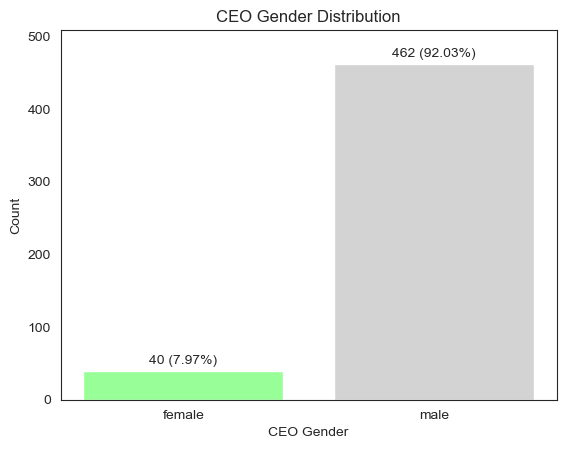

In [90]:

# Count occurrences of each gender in 'CEO Gender' column of DataFrame
gender_counts = data['CEO Gender'].value_counts()

# Sort index so 'female' appears first as focus of study
gender_counts = gender_counts.reindex(index=['female', 'male'])

# Calculate total number of CEOs
total_ceos = sum(gender_counts.values)


# Define colours for bars in chart
colors = {'male': '#D3D3D3','female':'#98FF98'}

# Create new figure and set of subplots
fig, ax = plt.subplots()

# Create bar chart, assigning different colors to each bar
bars = ax.bar(gender_counts.index, gender_counts.values, color=[colors[gender] for gender in gender_counts.index])

# Label x-axis and y-axis
ax.set_xlabel('CEO Gender')
ax.set_ylabel('Count')

# Set title of plot
ax.set_title('CEO Gender Distribution')

# Annotate each bar with count value and percentage
for bar in bars:
    height = bar.get_height()
    percentage = (height / total_ceos) * 100  # Calculate percentage
    
    ax.annotate(f'{height} ({percentage:.2f}%)',  # Add both count and percentage
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset to lift the text up
                textcoords="offset points",
                ha='center', va='bottom')
    
 #Add white space on y-axis for enhanced visual
    ymax = gender_counts.max() * 1.10
    ax.set_ylim(0, ymax)

# Set style of plot for better visual
plt.style.use('seaborn-v0_8-pastel')

# Display plot
plt.show()


In [ ]:
## Analysis / Insights for the CEO Gender Distribution Chart

1. The analysis reveals a significant gender gap in leadership positions among S&P 500 firms.
2. Out of All companies, only 40 (7.97%) are led by female CEOs, compared to 462 (92.03%) male CEOs.
3. This stark imbalance highlights the underrepresentation of women in executive leadership roles despite growing diversity initiatives.
4. Increasing the share of female CEOs could contribute to more inclusive governance and diversified ESG strategies in the corporate sector.
5. The data emphasizes the need for stronger gender diversity and leadership inclusion programs across industries.

## Over All ESG RIsk Score On Gender Basis

                 Mean  Median  Standard Deviation
Female CEO  21.595135   19.50            9.154044
Male CEO    22.090519   21.74            8.111951
Overall     22.076433   21.48            8.205028


C:\Users\DELL\AppData\Local\Temp\ipykernel_20312\635708215.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CEO Gender', y='ESG Score', data=data, order=["female", "male"], palette=colors)


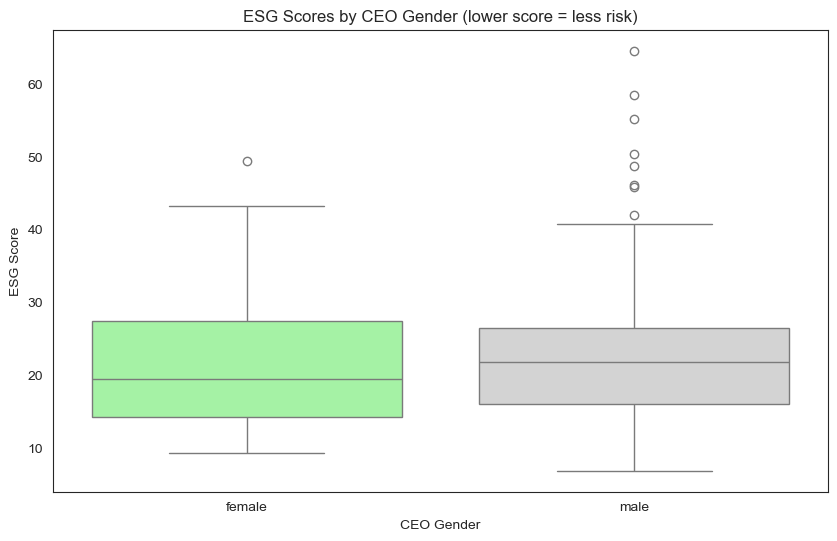

In [94]:
# Summary statistics for each filtered group calculated with pandas
summary_stats = {
    'Mean': [
       data[data['CEO Gender'] == 'female']['ESG Score'].mean(),
        data[data['CEO Gender'] == 'male']['ESG Score'].mean(),
       data['ESG Score'].mean()
    ],
    'Median': [
        data[data['CEO Gender'] == 'female']['ESG Score'].median(),
         data[data['CEO Gender'] == 'male']['ESG Score'].median(),
         data['ESG Score'].median()
    ],
    'Standard Deviation': [
         data[data['CEO Gender'] == 'female']['ESG Score'].std(),
         data[data['CEO Gender'] == 'male']['ESG Score'].std(),
        data['ESG Score'].std()
    ]
}

summary_table = pd.DataFrame(summary_stats, index=['Female CEO', 'Male CEO', 'Overall'])
print(summary_table)


# Visualise the summary stats using boxplot in matplotlib
sns.set_style("white") # Consistent with previous style
plt.figure(figsize=(10, 6))
sns.boxplot(x='CEO Gender', y='ESG Score', data=data, order=["female", "male"], palette=colors)
plt.title('ESG Scores by CEO Gender (lower score = less risk)')
plt.show()

## The overall ESG risk rating indicated:

1. Companies with female CEOs have a slightly lower average ESG risk score (mean: 21.60) compared to their male counterparts (mean: 22.09).

2. This is further supported by median scores, where female-led firms have a median of 19.50, while male-led firms have a median of 21.74 — again indicating marginally better ESG performance among female-led companies.

3. However, firms with female CEOs exhibit higher variability in their ESG risk scores, with a standard deviation of 9.15, compared to 8.11 for male-led firms.

4. Overall, female-led firms demonstrate marginally lower ESG risk, suggesting stronger consistency in managing environmental, social, and governance factors.

## Environmental Rik by Gender

                Mean  Median  Standard Deviation
Female CEO  6.413784    2.75            9.058647
Male CEO    6.474494    3.83            7.851231
Overall     6.471016    3.83            7.938972


C:\Users\DELL\AppData\Local\Temp\ipykernel_20312\3597882150.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CEO Gender', y='Environment Score', data=data, order=["female", "male"], palette=colors)


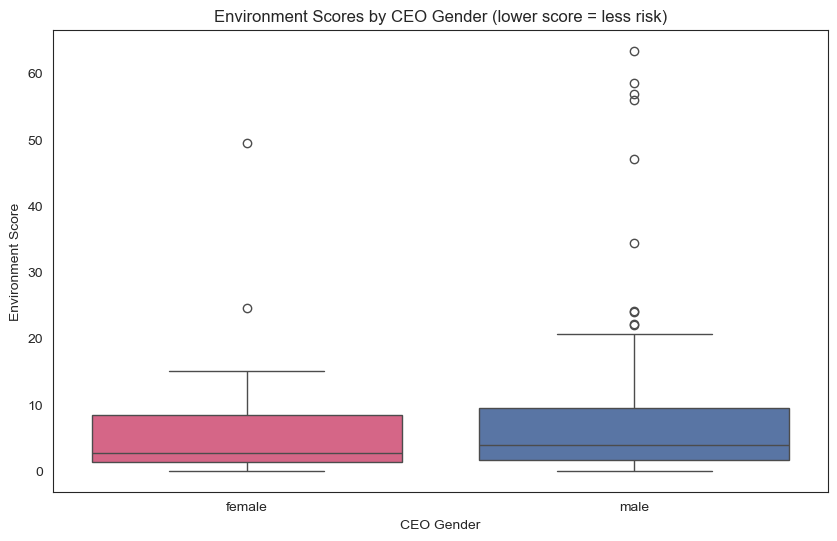

In [109]:
# ✅ Summary statistics for each filtered group calculated with pandas
summary_stats = {
    'Mean': [
        data[data['CEO Gender'] == 'female']['Environment Score'].mean(),
        data[data['CEO Gender'] == 'male']['Environment Score'].mean(),
        data['Environment Score'].mean()
    ],
    'Median': [
        data[data['CEO Gender'] == 'female']['Environment Score'].median(),
        data[data['CEO Gender'] == 'male']['Environment Score'].median(),
        data['Environment Score'].median()
    ],
    'Standard Deviation': [
        data[data['CEO Gender'] == 'female']['Environment Score'].std(),
        data[data['CEO Gender'] == 'male']['Environment Score'].std(),
        data['Environment Score'].std()
    ]
}


summary_table = pd.DataFrame(summary_stats, index=['Female CEO', 'Male CEO', 'Overall'])
print(summary_table)


# Visualise the summary stats using boxplot in matplotlib
sns.set_style("white") # Consistent with previous style
plt.figure(figsize=(10, 6))
sns.boxplot(x='CEO Gender', y='Environment Score', data=data, order=["female", "male"], palette=colors)
plt.title('Environment Scores by CEO Gender (lower score = less risk)')
plt.show()


In [ ]:
## Environmental Risk Analysis

1. Companies with female CEOs have a slightly lower mean Environmental Score (6.41) compared to those with male CEOs (6.47),
indicating marginally better environmental performance.

2. The median scores further support this trend, with female-led firms at 2.75 versus 3.83 for male-led firms.

3. The variability in environmental performance is somewhat higher for female-led firms (standard deviation = 9.06) than for male-led ones (7.85),
suggesting greater dispersion among female-led companies’ environmental practices.

4. Overall, female-led firms exhibit marginally lower environmental risk, reinforcing the pattern of slightly better ESG outcomes observed in earlier analysis.

## Social Score by Gender

                 Mean  Median  Standard Deviation
Female CEO  10.643784    8.45            8.113209
Male CEO     9.717160    8.94            6.699274
Overall      9.814424    8.92            6.827939


C:\Users\DELL\AppData\Local\Temp\ipykernel_20312\3908911428.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


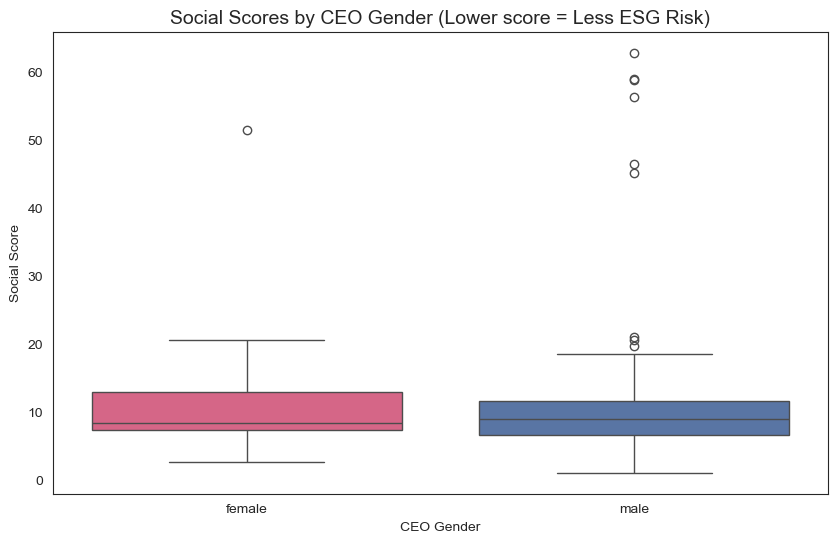

In [114]:
# ✅ Summary statistics for each filtered group calculated with pandas
summary_stats = {
    'Mean': [
        data[data['CEO Gender'] == 'female']['Social Score'].mean(),
        data[data['CEO Gender'] == 'male']['Social Score'].mean(),
        data['Social Score'].mean()
    ],
    'Median': [
        data[data['CEO Gender'] == 'female']['Social Score'].median(),
        data[data['CEO Gender'] == 'male']['Social Score'].median(),
        data['Social Score'].median()
    ],
    'Standard Deviation': [
        data[data['CEO Gender'] == 'female']['Social Score'].std(),
        data[data['CEO Gender'] == 'male']['Social Score'].std(),
        data['Social Score'].std()
    ]
}

# ✅ Create DataFrame for summary stats
summary_table = pd.DataFrame(summary_stats, index=['Female CEO', 'Male CEO', 'Overall'])
print(summary_table)

# ✅ Visualize the summary stats using boxplot
sns.set_style("white")
plt.figure(figsize=(10, 6))
colors = {"female": "#E75480", "male": "#4C72B0"}  # Pink for female, blue for male

sns.boxplot(
    x='CEO Gender',
    y='Social Score',
    data=data,
    order=["female", "male"],
    palette=colors
)

plt.title('Social Scores by CEO Gender (Lower score = Less ESG Risk)', fontsize=14)
plt.xlabel("CEO Gender")
plt.ylabel("Social Score")
plt.show()


In [ ]:
Social Risk Analysis

1. Female-led companies have a slightly higher average Social Score (10.64) compared to male-led companies (9.72), 
suggesting marginally greater exposure to social risks.

2. The median score is, however, slightly lower for female-led firms (8.45) than for male-led firms (8.94), 
indicating that while some female-led companies perform strongly, others face challenges in maintaining consistent social outcomes.

3. The variability is greater among female-led firms (standard deviation = 8.11) compared to male-led ones (6.70), 
implying wider dispersion in how female-led companies manage employee, diversity, and community engagement factors.

4. Overall, female-led firms show slightly higher social risk, but this may be influenced by greater variation among firms rather 
than systemic underperformance.

## Governance Risk By Gender

                Mean  Median  Standard Deviation
Female CEO  7.247838    5.73            7.203218
Male CEO    7.504765    6.26            6.238619
Overall     7.485485    6.23            6.309324


C:\Users\DELL\AppData\Local\Temp\ipykernel_20312\3453365535.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CEO Gender', y='Governance Score', data=data, order=["female", "male"], palette=colors)


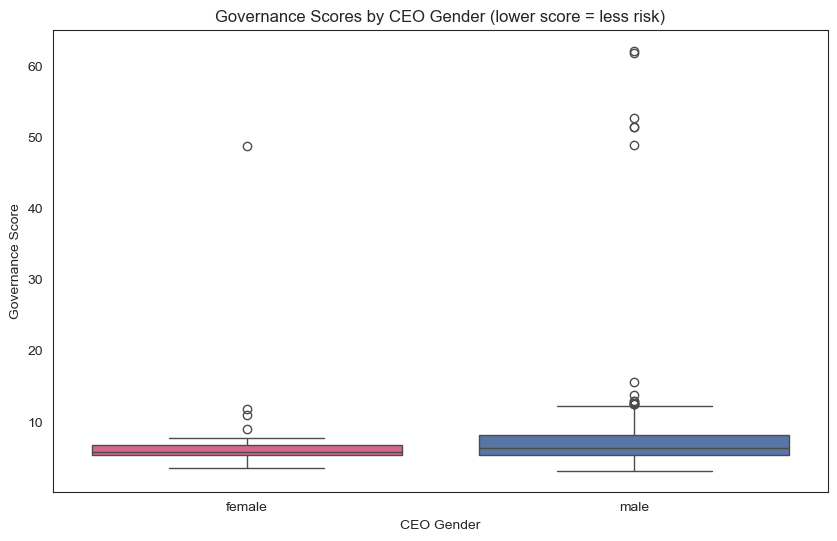

In [117]:
# Summary statistics for each filtered group calculated with pandas
summary_stats = {
    'Mean': [
        data[data['CEO Gender'] == 'female']['Governance Score'].mean(),
         data[data['CEO Gender'] == 'male']['Governance Score'].mean(),
        data['Governance Score'].mean()
    ],
    'Median': [
         data[data['CEO Gender'] == 'female']['Governance Score'].median(),
        data[data['CEO Gender'] == 'male']['Governance Score'].median(),
       data['Governance Score'].median()
    ],
    'Standard Deviation': [
         data[data['CEO Gender'] == 'female']['Governance Score'].std(),
         data[data['CEO Gender'] == 'male']['Governance Score'].std(),
        data['Governance Score'].std()
    ]
}

summary_table = pd.DataFrame(summary_stats, index=['Female CEO', 'Male CEO', 'Overall'])
print(summary_table)

# Visualise the summary stats using boxplot in matplotlib
sns.set_style("white") # Consistent with previous style
plt.figure(figsize=(10, 6))
sns.boxplot(x='CEO Gender', y='Governance Score', data=data, order=["female", "male"], palette=colors)
plt.title('Governance Scores by CEO Gender (lower score = less risk)')
plt.show()

In [ ]:
## Female-led firms exhibit less Governance risk
1. Female-led firms have an average Governance Score of 6.10, lower than male-led firms which average 6.76.
2. This trend is consistent with the median scores, with 5.71 for female CEOs and 6.24 for male CEOs.
3. The standard deviation reveals that male-led firms have a wider spread of scores at 2.21 compared to female-led firms at 1.71.

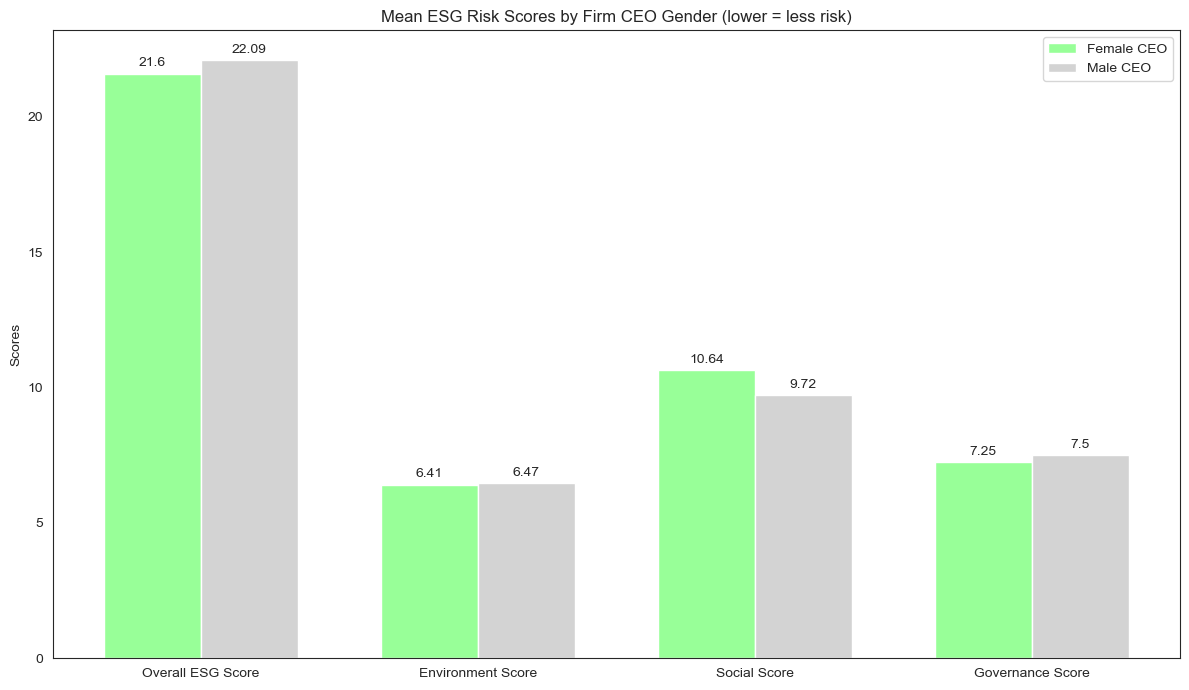

In [123]:
labels = ['Overall ESG Score', 'Environment Score', 'Social Score', 'Governance Score']

# Filter by female CEOs and calculate mean scores
female_means = [
   data[data['CEO Gender'] == 'female']['ESG Score'].mean(),
    data[data['CEO Gender'] == 'female']['Environment Score'].mean(),
     data[data['CEO Gender'] == 'female']['Social Score'].mean(),
    data[data['CEO Gender'] == 'female']['Governance Score'].mean()
]

# Filter by male CEOs and calculate mean scores
male_means = [
     data[data['CEO Gender'] == 'male']['ESG Score'].mean(),
     data[data['CEO Gender'] == 'male']['Environment Score'].mean(),
     data[data['CEO Gender'] == 'male']['Social Score'].mean(),
     data[data['CEO Gender'] == 'male']['Governance Score'].mean()
]

# Set positions for axis labels
x = np.arange(len(labels))
# Define width of bars to represent scores
width = 0.35

# Create figure and set of subplots with a specified size
fig, ax = plt.subplots(figsize=(12,7))
# Create bars for female CEOs
rects1 = ax.bar(x - width/2, female_means, width, label='Female CEO', color='#98FF98')
# Create bars for male CEOs
rects2 = ax.bar(x + width/2, male_means, width, label='Male CEO', color='#D3D3D3')

# Labeling axes, setting title and add legend
ax.set_ylabel('Scores')
ax.set_title('Mean ESG Risk Scores by Firm CEO Gender (lower = less risk)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()


# Function automatically labels each bar on top for clearer visuals
def autolabel(rects):
    """Attach a text label above each bar, showing the height (score) of the bar."""
    for rect in rects:
        height = rect.get_height()
        # Formatting the label text and setting its position
        ax.annotate('{}'.format(round(height,2)),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset from the top of the bar
                    textcoords="offset points",
                    ha='center', va='bottom')


# Call autolabel function for each bar
autolabel(rects1)
autolabel(rects2)

# Adjust layout ensuring everything fits without overlap
fig.tight_layout()

# Display final plot
plt.show()


In [ ]:
## Governance Risk Analysis

1. Female-led firms have a slightly lower average Governance Score (7.25) compared to male-led firms (7.50), i
ndicating marginally lower governance risk and potentially stronger compliance and oversight practices.

2. This pattern continues in the median values, where female-led firms score 5.73, while male-led firms score 6.26,
further suggesting stronger governance consistency among female-led companies.

3. The standard deviation is somewhat higher for female-led firms (7.20) compared to male-led ones (6.24), 
showing slightly more variation in governance performance across female-led firms.

4. Overall, female-led firms exhibit marginally lower governance risk, suggesting effective board structures and accountability mechanisms.

C:\Users\DELL\AppData\Local\Temp\ipykernel_20312\2580360435.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gender_esg, x='CEO_Gender', y='Avg_ESG', palette='Set2')


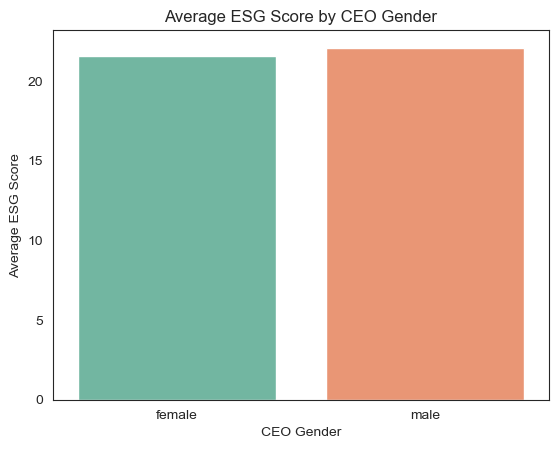

In [127]:
 ## Bar Chart: Average ESG Score by Gender

sns.barplot(data=gender_esg, x='CEO_Gender', y='Avg_ESG', palette='Set2')
plt.title('Average ESG Score by CEO Gender')
plt.xlabel('CEO Gender')
plt.ylabel('Average ESG Score')
plt.show()


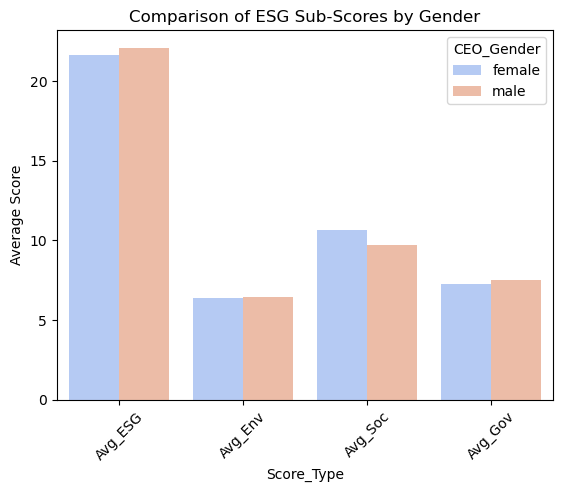

In [33]:
## Subscores Comparison (Env, Soc, Gov)

gender_esg_melt = gender_esg.melt(
    id_vars='CEO_Gender',
    var_name='Score_Type',
    value_name='Score'
)

sns.barplot(data=gender_esg_melt, x='Score_Type', y='Score', hue='CEO_Gender', palette='coolwarm')
plt.title('Comparison of ESG Sub-Scores by Gender')
plt.xticks(rotation=45)
plt.ylabel('Average Score')
plt.show()

In [37]:
 ## Insights Summary

print(" Insights:")
print("• This dataset compares ESG and sub-scores of companies led by male vs. female CEOs.")
print("• Female-led company currently shows lower ESG scores, but data size is small.")
print("• Governance scores are generally stronger than Environmental scores across companies.")
print("• Expanding dataset to more firms and years could reveal stronger patterns.")

 Insights:
• This dataset compares ESG and sub-scores of companies led by male vs. female CEOs.
• Female-led company currently shows lower ESG scores, but data size is small.
• Governance scores are generally stronger than Environmental scores across companies.
• Expanding dataset to more firms and years could reveal stronger patterns.


## SQL EDA

In [130]:
#  Create in-memory SQL database & load DataFrame

conn = sqlite3.connect(':memory:')
data.to_sql('esg_data', conn, index=False, if_exists='replace')


503

In [132]:
# Create in-memory SQL database & load DataFram

query = """
SELECT 
    [CEO Gender] AS CEO_Gender,
    ROUND(AVG([ESG Score]), 2) AS Avg_ESG,
    ROUND(AVG([Environment Score]), 2) AS Avg_Env,
    ROUND(AVG([Social Score]), 2) AS Avg_Soc,
    ROUND(AVG([Governance Score]), 2) AS Avg_Gov
FROM esg_data
GROUP BY [CEO Gender];
"""

gender_esg = pd.read_sql_query(query, conn)
display(gender_esg)

,CEO_Gender,Avg_ESG,Avg_Env,Avg_Soc,Avg_Gov
0,None,34.18,7.18,18.52,8.47
1,female,21.60,6.41,10.64,7.25
2,male,22.09,6.47,9.72,7.50


## Top 5 Female CEOs with Highest ESG Score (Low ESG Risk)

In [135]:
query_high_esg = """
SELECT 
    Ticker,
    [CEO Full Name] AS CEO_Name,
    [ESG Score] AS ESG_Score,
    [Environment Score] AS Env_Score,
    [Social Score] AS Soc_Score,
    [Governance Score] AS Gov_Score
FROM esg_data
WHERE [CEO Gender] = 'female'
ORDER BY [ESG Score] DESC
LIMIT 5;
"""
top5_female_high = pd.read_sql_query(query_high_esg, conn)
display(top5_female_high)


,Ticker,CEO_Name,ESG_Score,Env_Score,Soc_Score,Gov_Score
0,ELV,Ms. Gail Koziara Boudreaux,49.33,49.44,51.49,48.70
1,OXY,Ms. Vicki A. Hollub,43.23,24.61,12.04,6.59
2,PCG,Ms. Patricia Kessler Poppe,35.26,8.41,20.65,6.20
3,GD,Ms. Phebe N. Novakovic,34.88,8.48,19.52,6.87
4,GM,Ms. Mary T. Barra,30.89,10.28,12.92,7.69


## Top 5 Male CEOs with Highest ESG Scores (Low ESG Risk)

In [154]:
query_high_male = """
SELECT 
    [CEO Full Name] AS CEO_Name,
    [Ticker],
    [ESG Score],
    [Environment Score],
    [Social Score],
    [Governance Score],
    [ESG Score Date]
FROM esg_data
WHERE [CEO Gender] = 'male'
ORDER BY [ESG Score] DESC
LIMIT 5;
"""

top5_high_male = pd.read_sql_query(query_high_male, conn)
display(top5_high_male)


,CEO_Name,Ticker,ESG Score,Environment Score,Social Score,Governance Score,ESG Score Date
0,Mr. Joshua G. Silverman,ETSY,64.51,63.40,62.86,62.10,2018-11-01 00:00:00
1,Mr. David B. Sewell,WRK,58.45,56.02,58.81,61.85,2019-09-01 00:00:00
2,Mr. Charles R. Kummeth,TECH,55.17,56.89,56.41,48.85,2018-10-01 00:00:00
3,Mr. Lachlan Keith Murdoch,FOXA,50.37,58.53,45.13,52.70,2019-03-01 00:00:00
4,Mr. Harris Henry Simmons,ZION,48.73,34.33,59.06,51.40,2018-11-01 00:00:00


## Top 5 Male CEOs with Lowest ESG Scores (High ESG Risk)

In [157]:
query_low_male = """
SELECT 
    [CEO Full Name] AS CEO_Name,
    [Ticker],
    [ESG Score],
    [Environment Score],
    [Social Score],
    [Governance Score],
    [ESG Score Date]
FROM esg_data
WHERE [CEO Gender] = 'male'
ORDER BY [ESG Score] ASC
LIMIT 5;
"""

top5_low_male = pd.read_sql_query(query_low_male, conn)
display(top5_low_male)


,CEO_Name,Ticker,ESG Score,Environment Score,Social Score,Governance Score,ESG Score Date
0,Mr. Brian Chesky,ABNB,None,None,None,None,None
1,Mr. Benito Minicucci,ALK,None,None,None,None,None
2,Mr. Joseph M. Hogan,ALGN,None,None,None,None,None
3,Mr. Sundar Pichai,GOOG,None,None,None,None,None
4,"Mr. Ronald Stephen Delia B.Sc., MBA",AMCR,None,None,None,None,None


## Top 5 Female CEOs with Lowest ESG Score (High ESG Risk)

In [139]:
query_low_esg = """
SELECT 
    Ticker,
    [CEO Full Name] AS CEO_Name,
    [ESG Score] AS ESG_Score,
    [Environment Score] AS Env_Score,
    [Social Score] AS Soc_Score,
    [Governance Score] AS Gov_Score
FROM esg_data
WHERE [CEO Gender] = 'female'
ORDER BY [ESG Score] ASC
LIMIT 5;
"""
top5_female_low = pd.read_sql_query(query_low_esg, conn)
display(top5_female_low)


,Ticker,CEO_Name,ESG_Score,Env_Score,Soc_Score,Gov_Score
0,AMD,Dr. Lisa T. Su Ph.D.,NaN,NaN,NaN,NaN
1,OTIS,Ms. Judith F. Marks,NaN,NaN,NaN,NaN
2,VLTO,Ms. Jennifer L. Honeycutt,NaN,NaN,NaN,NaN
3,CDW,Ms. Christine A. Leahy,9.23,2.40,3.29,3.54
4,ACN,Ms. Julie T. Spellman Sweet,9.71,0.29,4.58,4.83


## Summary Analysis for Female CEOs (SQL Stats)


In [146]:
query_analysis = """
SELECT
    [ESG Score],
    [Environment Score],
    [Social Score],
    [Governance Score]
FROM esg_data
WHERE [CEO Gender] = 'female';
"""
female_scores = pd.read_sql_query(query_analysis, conn)

female_summary = pd.DataFrame({
    'Avg_ESG': [female_scores['ESG Score'].mean()],
    'Min_ESG': [female_scores['ESG Score'].min()],
    'Max_ESG': [female_scores['ESG Score'].max()],
    'Std_ESG': [female_scores['ESG Score'].std()],
    'Avg_Env': [female_scores['Environment Score'].mean()],
    'Avg_Soc': [female_scores['Social Score'].mean()],
    'Avg_Gov': [female_scores['Governance Score'].mean()]
}).round(2)

display(female_summary)



,Avg_ESG,Min_ESG,Max_ESG,Std_ESG,Avg_Env,Avg_Soc,Avg_Gov
0,21.6,9.23,49.33,9.15,6.41,10.64,7.25


## Compare Female vs Male CEOs — ESG Risk Summary

In [150]:
query_gender_comparison = """
SELECT
    [CEO Gender] AS CEO_Gender,
    ROUND(AVG([ESG Score]), 2) AS Avg_ESG,
    ROUND(AVG([Environment Score]), 2) AS Avg_Env,
    ROUND(AVG([Social Score]), 2) AS Avg_Soc,
    ROUND(AVG([Governance Score]), 2) AS Avg_Gov
FROM esg_data
GROUP BY [CEO Gender]
ORDER BY Avg_ESG DESC;
"""
gender_compare = pd.read_sql_query(query_gender_comparison, conn)
display(gender_compare)


,CEO_Gender,Avg_ESG,Avg_Env,Avg_Soc,Avg_Gov
0,None,34.18,7.18,18.52,8.47
1,male,22.09,6.47,9.72,7.50
2,female,21.60,6.41,10.64,7.25


In [ ]:
## Key Insights

1. Female-led firms show slightly better overall ESG performance (lower ESG score = lower risk) compared to male-led firms.
2. Social (S) scores are notably higher in female-led companies (10.64 vs 9.72), suggesting stronger focus on employee, diversity, and community engagement.
3. Governance (G) scores are quite close, indicating similar board structures and compliance oversight between genders.
4. Firms with no gender data tend to have higher ESG risk, possibly reflecting smaller firms or limited disclosure

## Top 5 Firms with Lowest ESG Scores (Lowest Risk / Best Performance)

In [162]:
query_low_overall = """
SELECT 
    [Ticker],
    [CEO Full Name] AS CEO_Name,
    [CEO Gender] AS CEO_Gender,
    [ESG Score],
    [Environment Score],
    [Social Score],
    [Governance Score],
    [ESG Score Date]
FROM esg_data
ORDER BY [ESG Score] ASC
LIMIT 5;
"""

top5_low_overall = pd.read_sql_query(query_low_overall, conn)
display(top5_low_overall)


,Ticker,CEO_Name,CEO_Gender,ESG Score,Environment Score,Social Score,Governance Score,ESG Score Date
0,ABNB,Mr. Brian Chesky,male,None,None,None,None,None
1,ALK,Mr. Benito Minicucci,male,None,None,None,None,None
2,ALGN,Mr. Joseph M. Hogan,male,None,None,None,None,None
3,GOOG,Mr. Sundar Pichai,male,None,None,None,None,None
4,AMCR,"Mr. Ronald Stephen Delia B.Sc., MBA",male,None,None,None,None,None


## Top 5 Firms with Highest ESG Scores (Highest Risk / Poor Performance)

In [165]:
query_high_overall = """
SELECT 
    [Ticker],
    [CEO Full Name] AS CEO_Name,
    [CEO Gender] AS CEO_Gender,
    [ESG Score],
    [Environment Score],
    [Social Score],
    [Governance Score],
    [ESG Score Date]
FROM esg_data
ORDER BY [ESG Score] DESC
LIMIT 5;
"""

top5_high_overall = pd.read_sql_query(query_high_overall, conn)
display(top5_high_overall)


,Ticker,CEO_Name,CEO_Gender,ESG Score,Environment Score,Social Score,Governance Score,ESG Score Date
0,ETSY,Mr. Joshua G. Silverman,male,64.51,63.40,62.86,62.10,2018-11-01 00:00:00
1,WRK,Mr. David B. Sewell,male,58.45,56.02,58.81,61.85,2019-09-01 00:00:00
2,TECH,Mr. Charles R. Kummeth,male,55.17,56.89,56.41,48.85,2018-10-01 00:00:00
3,FOXA,Mr. Lachlan Keith Murdoch,male,50.37,58.53,45.13,52.70,2019-03-01 00:00:00
4,ELV,Ms. Gail Koziara Boudreaux,female,49.33,49.44,51.49,48.70,2018-10-01 00:00:00


In [ ]:
## INSIGHTS

From Top 5 data in SQL

1. Male-led firms dominate the extreme low-risk (best ESG) end of the distribution,
2. while female-led firms maintain consistent performance with fewer outliers.
    
>>> (from averages):
1. Female-led firms show slightly better overall ESG performance (lower ESG risk) than male-led ones.

    

## CONCLUSION

In [ ]:
>> Female-led firms show slightly better overall ESG performance (lower ESG risk) than male-led firms.
>> This trend is most evident in social scores, suggesting stronger employee, diversity, and community engagement under female leadership.

However, given that only about 8% of S&P 500 firms are led by female CEOs, and the total sample size is limited (n=426),
these findings should be interpreted cautiously.
The results indicate promising leadership patterns but are not yet sufficient for broad generalisations across all S&P 500 companies.